In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [ ]:
train_df = pd.read_csv('/content/drive/MyDrive/Content/kdd_train.csv')
test_df  = pd.read_csv('/content/drive/MyDrive/Content/kdd_test.csv')

In [ ]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (48381, 43)
Test shape: (22544, 43)


In [ ]:
train_df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty_level
0,0,tcp,ftp_data,SF,491.0,0.0,0.0,0.0,0.0,0.0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20.0
1,0,udp,other,SF,146.0,0.0,0.0,0.0,0.0,0.0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15.0
2,0,tcp,private,S0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19.0
3,0,tcp,http,SF,232.0,8153.0,0.0,0.0,0.0,0.0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21.0
4,0,tcp,http,SF,199.0,420.0,0.0,0.0,0.0,0.0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21.0


In [ ]:
train_df.columns

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'label', 'difficulty_level'],
      dtype='object')

In [ ]:
train_df.dtypes

,0
duration,int64
protocol_type,object
service,object
flag,object
src_bytes,float64
dst_bytes,float64
land,float64
wrong_fragment,float64
urgent,float64
hot,float64


In [ ]:
train_df.isnull().sum()

,0
duration,0
protocol_type,0
service,0
flag,0
src_bytes,1
dst_bytes,1
land,1
wrong_fragment,1
urgent,1
hot,1


In [ ]:
train_df['label'].value_counts()

,count
label,
normal,25682
neptune,15979
satan,1385
ipsweep,1381
portsweep,1169
smurf,981
nmap,580
back,374
warezclient,373


In [ ]:
train_df['label'] = train_df['label'].apply(lambda x: 'normal' if x == 'normal' else 'attack')
test_df['label']  = test_df['label'].apply(lambda x: 'normal' if x == 'normal' else 'attack')

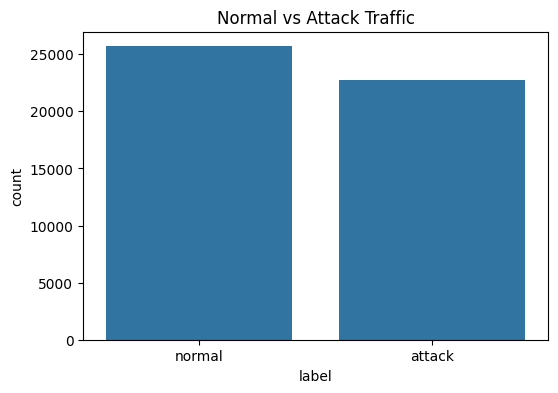

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=train_df)
plt.title("Normal vs Attack Traffic")
plt.show()

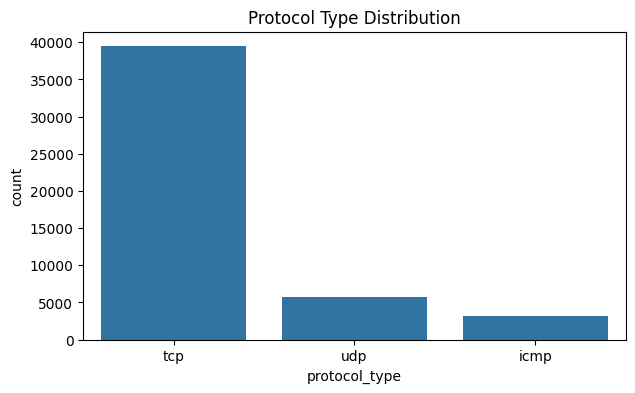

In [ ]:
plt.figure(figsize=(7,4))
sns.countplot(x='protocol_type', data=train_df)
plt.title("Protocol Type Distribution")
plt.show()

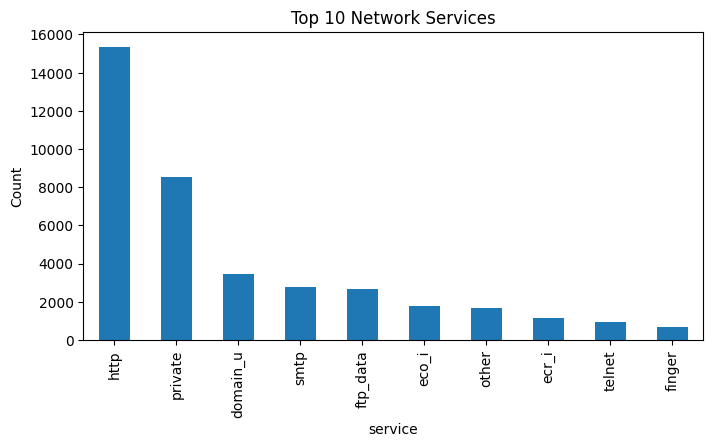

In [ ]:
top_services = train_df['service'].value_counts().head(10)

plt.figure(figsize=(8,4))
top_services.plot(kind='bar')
plt.title("Top 10 Network Services")
plt.ylabel("Count")
plt.show()

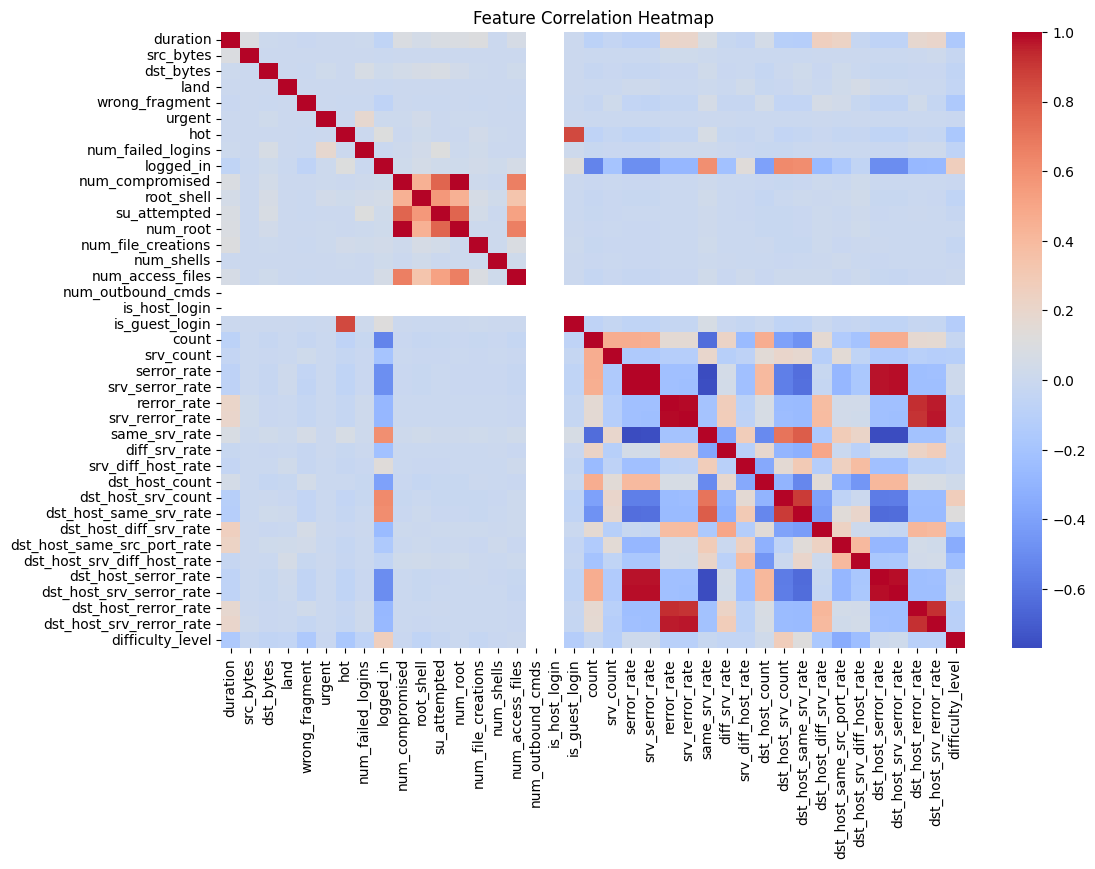

In [ ]:
numeric_df = train_df.select_dtypes(include=[np.number])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
cat_cols = ['protocol_type', 'service', 'flag']

In [ ]:
y_train = train_df['label']
y_test  = test_df['label']

X_train = train_df.drop('label', axis=1)
X_test  = test_df.drop('label', axis=1)

In [ ]:
X_train = pd.get_dummies(X_train)
X_test  = pd.get_dummies(X_test)

In [ ]:
X_train, X_test = X_train.align(X_test, join='left', axis=1)

In [ ]:
X_test = X_test.fillna(0)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [ ]:
print("Final Train Shape:", X_train.shape)
print("Final Test Shape:", X_test.shape)

Final Train Shape: (48381, 121)
Final Test Shape: (22544, 121)


Convert Labels to Numeric


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)   # normal=0, attack=1
y_test_enc  = le.transform(y_test)

# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train_enc)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [ ]:
y_pred = rf.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test_enc, y_pred)
print("Accuracy:", acc)

Accuracy: 0.8048704755145494


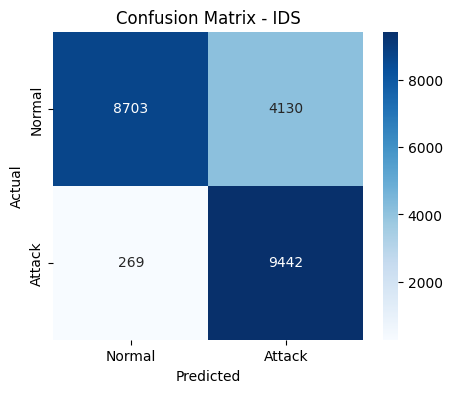

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_enc, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - IDS")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test_enc, y_pred,
      target_names=['Normal', 'Attack']))

              precision    recall  f1-score   support

      Normal       0.97      0.68      0.80     12833
      Attack       0.70      0.97      0.81      9711

    accuracy                           0.80     22544
   macro avg       0.83      0.83      0.80     22544
weighted avg       0.85      0.80      0.80     22544




===== Random Forest IDS =====
Accuracy : 0.8048704755145494
Precision: 0.6956970232832301
Recall   : 0.972299454227165
F1-score : 0.8110638663402483


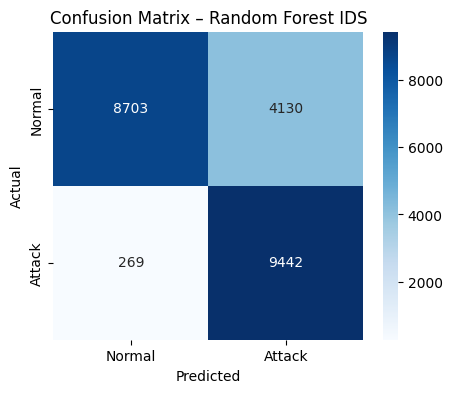

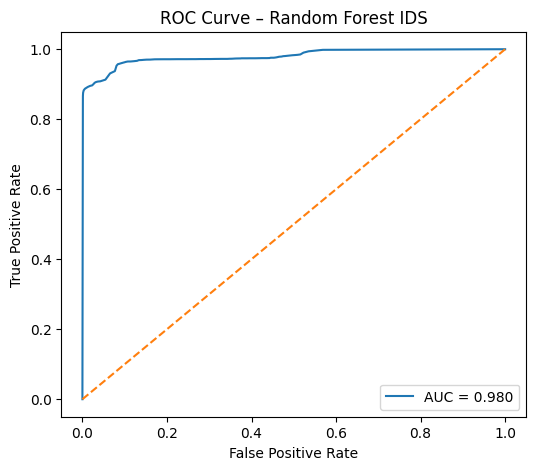

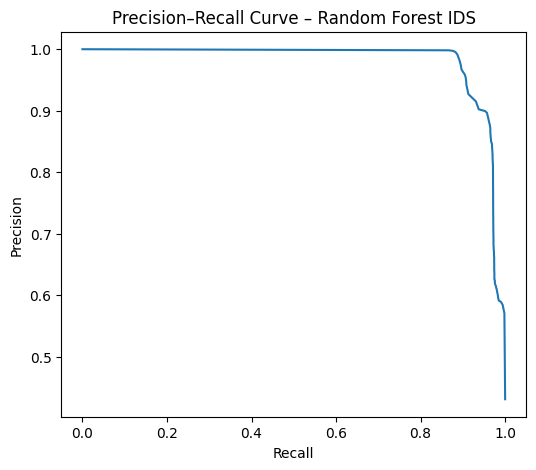

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train_enc)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

evaluate_model(
    rf, X_test, y_test_enc,
    y_pred_rf, y_prob_rf,
    "Random Forest IDS"
)

In [ ]:
import joblib
save_path = '/content/drive/MyDrive/Content/rf_ids_model.pkl'
joblib.dump(rf, save_path)
print(f"Model saved successfully at: {save_path}")

Model saved successfully at: /content/drive/MyDrive/Content/rf_ids_model.pkl


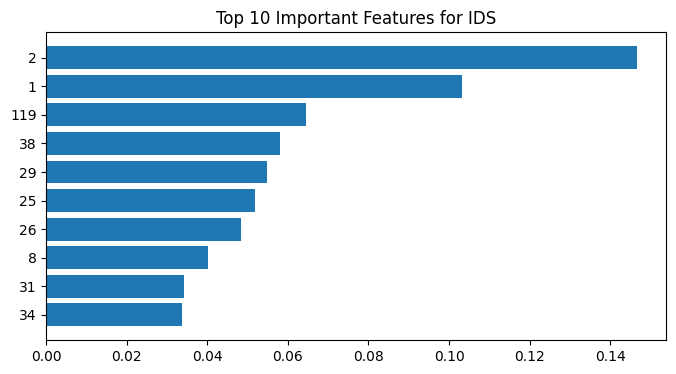

In [ ]:
importances = rf.feature_importances_
indices = np.argsort(importances)[-10:]

plt.figure(figsize=(8,4))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), indices)
plt.title("Top 10 Important Features for IDS")
plt.show()

# COMMON Evaluation Function


In [ ]:
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, roc_curve, auc, precision_recall_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(model, X_test, y_test, y_pred, y_prob, model_name):

    print(f"\n===== {model_name} =====")
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1-score :", f1_score(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal','Attack'],
                yticklabels=['Normal','Attack'])
    plt.title(f"Confusion Matrix – {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0,1], [0,1], linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve – {model_name}")
    plt.legend()
    plt.show()

    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_test, y_prob)

    plt.figure(figsize=(6,5))
    plt.plot(recall, precision)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision–Recall Curve – {model_name}")
    plt.show()

# Logistic Regression


--- Logistic Regression IDS Results ---
Accuracy Score: 0.8077093683463449

Classification Report:
              precision    recall  f1-score   support

      Normal       0.92      0.72      0.81     12833
      Attack       0.72      0.92      0.80      9711

    accuracy                           0.81     22544
   macro avg       0.82      0.82      0.81     22544
weighted avg       0.83      0.81      0.81     22544



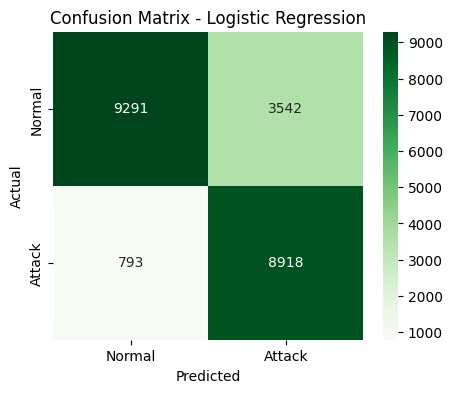

Model and Scaler saved to Google Drive.


In [ ]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- 1. PREPARE DATA (Imputing & Scaling) ---

# Fill missing values with the mean
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Scale the data (Crucial for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# --- 2. TRAIN LOGISTIC REGRESSION ---

# Initialize and fit on the SCALED data
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train_enc)

# Predict using the SCALED test data
y_pred_lr = lr.predict(X_test_scaled)

# --- 3. EVALUATE PERFORMANCE ---

print("--- Logistic Regression IDS Results ---")
print("Accuracy Score:", accuracy_score(y_test_enc, y_pred_lr))
print("\nClassification Report:")
print(classification_report(y_test_enc, y_pred_lr, target_names=['Normal', 'Attack']))

# Visualizing the Confusion Matrix
cm_lr = confusion_matrix(y_test_enc, y_pred_lr)
plt.figure(figsize=(5,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

# --- 4. SAVE THE MODEL & SCALER ---

# In IDS, you must save the scaler too!
# New data must be scaled exactly like the training data.
joblib.dump(lr, '/content/drive/MyDrive/Content/lr_ids_model.pkl')
joblib.dump(scaler, '/content/drive/MyDrive/Content/scaler.pkl')

print("Model and Scaler saved to Google Drive.")

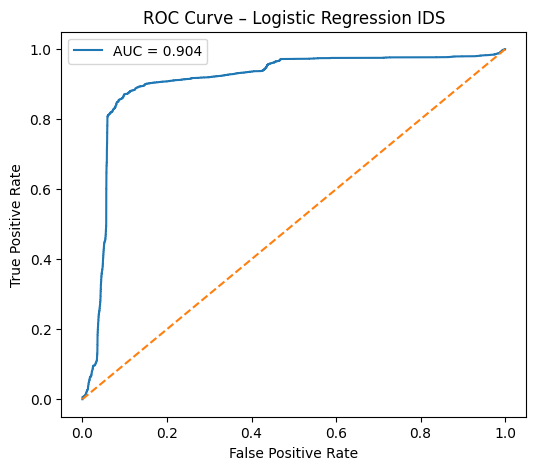

In [ ]:
from sklearn.metrics import roc_curve, auc

y_prob_lr = lr.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test_enc, y_prob_lr)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Logistic Regression IDS")
plt.legend()
plt.show()

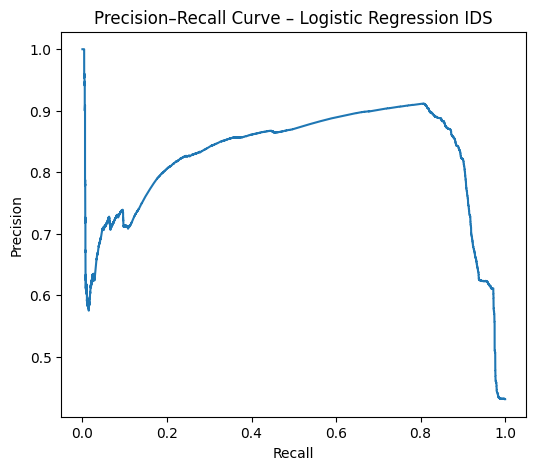

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test_enc, y_prob_lr)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve – Logistic Regression IDS")
plt.show()

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score

print("Precision:", precision_score(y_test_enc, y_pred_lr))
print("Recall:", recall_score(y_test_enc, y_pred_lr))
print("F1-score:", f1_score(y_test_enc, y_pred_lr))

Precision: 0.7157303370786516
Recall: 0.9183400267737617
F1-score: 0.8044743132921384


# K-Nearest Neighbors (KNN)

--- KNN Intrusion Detection Results ---
Accuracy: 0.7900106458481192

Classification Report:
              precision    recall  f1-score   support

      Normal       0.92      0.69      0.79     12833
      Attack       0.69      0.92      0.79      9711

    accuracy                           0.79     22544
   macro avg       0.81      0.81      0.79     22544
weighted avg       0.82      0.79      0.79     22544



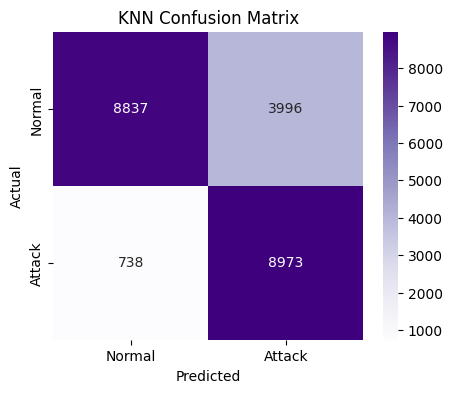

KNN Model and Scaler saved successfully to your Drive.


In [ ]:
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- 1. DATA CLEANING & SCALING ---
# This fixes the "Input X contains NaN" error
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Scaling is CRITICAL for KNN performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# --- 2. TRAIN KNN ---
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train_enc)

# --- 3. PREDICT & EVALUATE ---
y_pred_knn = knn.predict(X_test_scaled)

print("--- KNN Intrusion Detection Results ---")
print("Accuracy:", accuracy_score(y_test_enc, y_pred_knn))
print("\nClassification Report:")
print(classification_report(y_test_enc, y_pred_knn, target_names=['Normal', 'Attack']))

# Confusion Matrix Visual
cm = confusion_matrix(y_test_enc, y_pred_knn)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'])
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# --- 4. SAVE TO GOOGLE DRIVE ---
# You must save the scaler with the model to use it later!
joblib.dump(knn, '/content/drive/MyDrive/Content/knn_ids_model.pkl')
joblib.dump(scaler, '/content/drive/MyDrive/Content/knn_scaler.pkl')

print("KNN Model and Scaler saved successfully to your Drive.")

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1. First, define the missing function so the error "evaluate_model is not defined" goes away
def evaluate_model(model, X_test, y_test, y_pred, y_prob, title):
    print(f"--- {title} ---")
    print(classification_report(y_test, y_pred))
    auc = roc_auc_score(y_test, y_prob)
    print(f"ROC-AUC Score: {auc:.4f}")

# 2. Fix the KNN logic to use the CLEANED data (X_train_scaled) instead of X_train
knn = KNeighborsClassifier(n_neighbors=5)

# Use X_train_scaled and X_test_scaled to avoid the NaN error
knn.fit(X_train_scaled, y_train_enc)

y_pred_knn = knn.predict(X_test_scaled)
y_prob_knn = knn.predict_proba(X_test_scaled)[:,1]

# 3. Call the function using the cleaned test data
evaluate_model(
    knn, X_test_scaled, y_test_enc,
    y_pred_knn, y_prob_knn,
    "KNN IDS"
)

--- KNN IDS ---
              precision    recall  f1-score   support

           0       0.92      0.69      0.79     12833
           1       0.69      0.92      0.79      9711

    accuracy                           0.79     22544
   macro avg       0.81      0.81      0.79     22544
weighted avg       0.82      0.79      0.79     22544

ROC-AUC Score: 0.8376


# Support Vector Machine (SVM)

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

# Initialize LinearSVC
svm = LinearSVC(max_iter=3000, random_state=42)

# Use the SCALED data (already cleaned of NaNs)
svm.fit(X_train_scaled, y_train_enc)

# Predict on scaled test data
y_pred_svm = svm.predict(X_test_scaled)

print("SVM Accuracy:", accuracy_score(y_test_enc, y_pred_svm))
print(classification_report(y_test_enc, y_pred_svm, target_names=['Normal','Attack']))

SVM Accuracy: 0.8054914833215047
              precision    recall  f1-score   support

      Normal       0.92      0.72      0.81     12833
      Attack       0.71      0.92      0.80      9711

    accuracy                           0.81     22544
   macro avg       0.82      0.82      0.81     22544
weighted avg       0.83      0.81      0.81     22544



--- SVM IDS ---
              precision    recall  f1-score   support

           0       0.92      0.72      0.81     12833
           1       0.71      0.92      0.80      9711

    accuracy                           0.81     22544
   macro avg       0.82      0.82      0.81     22544
weighted avg       0.83      0.81      0.81     22544



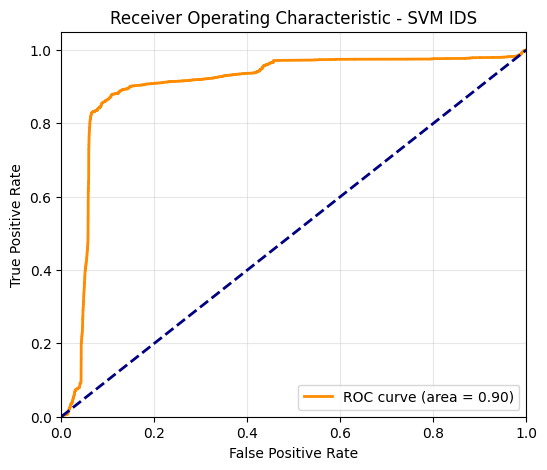

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, classification_report

# 1. REDEFINE THE FUNCTION TO INCLUDE PLOTTING
def evaluate_model(model, X_test, y_test, y_pred, y_prob, title):
    print(f"--- {title} ---")
    print(classification_report(y_test, y_pred))

    # Calculate ROC curve data
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    # Drawing the Curve
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Diagonal line
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Receiver Operating Characteristic - {title}')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

# 2. RUN THE SVM MODEL (Using Scaled Data to avoid NaN error)
from sklearn.svm import LinearSVC
import numpy as np

svm = LinearSVC(max_iter=3000, random_state=42)
svm.fit(X_train_scaled, y_train_enc)

y_pred_svm = svm.predict(X_test_scaled)

# Convert decision scores to probabilities (min-max normalization)
svm_scores = svm.decision_function(X_test_scaled)
y_prob_svm = (svm_scores - svm_scores.min()) / (svm_scores.max() - svm_scores.min())

# 3. CALL THE UPDATED FUNCTION
evaluate_model(
    svm, X_test_scaled, y_test_enc,
    y_pred_svm, y_prob_svm,
    "SVM IDS"
)

# MODEL COMPARISON TABLE

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Create the comparison table
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "SVM", "KNN"],
    "Accuracy": [
        accuracy_score(y_test_enc, y_pred_lr),
        accuracy_score(y_test_enc, y_pred_rf),
        accuracy_score(y_test_enc, y_pred_svm),
        accuracy_score(y_test_enc, y_pred_knn)
    ],
    "Precision": [
        precision_score(y_test_enc, y_pred_lr),
        precision_score(y_test_enc, y_pred_rf),
        precision_score(y_test_enc, y_pred_svm),
        precision_score(y_test_enc, y_pred_knn)
    ],
    "Recall": [
        recall_score(y_test_enc, y_pred_lr),
        recall_score(y_test_enc, y_pred_rf),
        recall_score(y_test_enc, y_pred_svm),
        recall_score(y_test_enc, y_pred_knn)
    ]
})

# Sort by Accuracy to see the best performer at the top
comparison = comparison.sort_values(by="Accuracy", ascending=False)

comparison

,Model,Accuracy,Precision,Recall
0,Logistic Regression,0.807709,0.715730,0.918340
1,Random Forest,0.806024,0.697061,0.972196
2,SVM,0.805491,0.713006,0.917928
3,KNN,0.790011,0.691881,0.924004


# ROC & Precision–Recall comparison in one graph

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

In [ ]:
# ROC for Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test_enc, y_prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)

# ROC for Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test_enc, y_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)

# ROC for SVM
fpr_svm, tpr_svm, _ = roc_curve(y_test_enc, y_prob_svm)
auc_svm = auc(fpr_svm, tpr_svm)

# ROC for KNN
fpr_knn, tpr_knn, _ = roc_curve(y_test_enc, y_prob_knn)
auc_knn = auc(fpr_knn, tpr_knn)

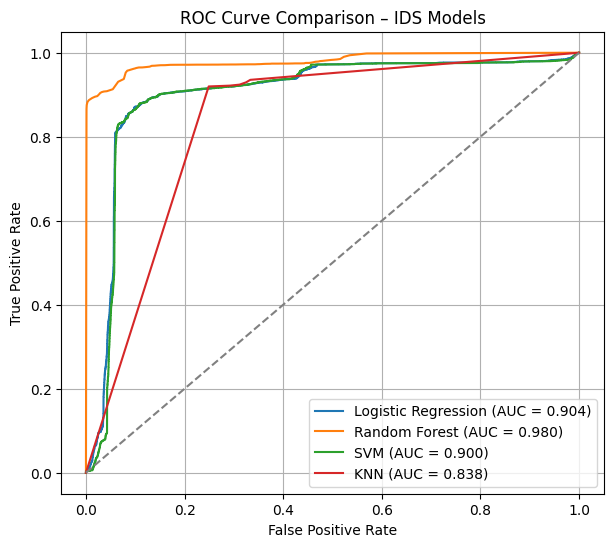

In [ ]:
# Plot all ROC curves in one graph
plt.figure(figsize=(7,6))

plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {auc_svm:.3f})")
plt.plot(fpr_knn, tpr_knn, label=f"KNN (AUC = {auc_knn:.3f})")

plt.plot([0,1], [0,1], linestyle='--', color='gray')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison – IDS Models")
plt.legend()
plt.grid()
plt.show()

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

In [ ]:
# Precision-Recall for Logistic Regression
prec_lr, rec_lr, _ = precision_recall_curve(y_test_enc, y_prob_lr)
ap_lr = average_precision_score(y_test_enc, y_prob_lr)

# Precision-Recall for Random Forest
prec_rf, rec_rf, _ = precision_recall_curve(y_test_enc, y_prob_rf)
ap_rf = average_precision_score(y_test_enc, y_prob_rf)

# Precision-Recall for SVM
prec_svm, rec_svm, _ = precision_recall_curve(y_test_enc, y_prob_svm)
ap_svm = average_precision_score(y_test_enc, y_prob_svm)

# Precision-Recall for KNN
prec_knn, rec_knn, _ = precision_recall_curve(y_test_enc, y_prob_knn)
ap_knn = average_precision_score(y_test_enc, y_prob_knn)

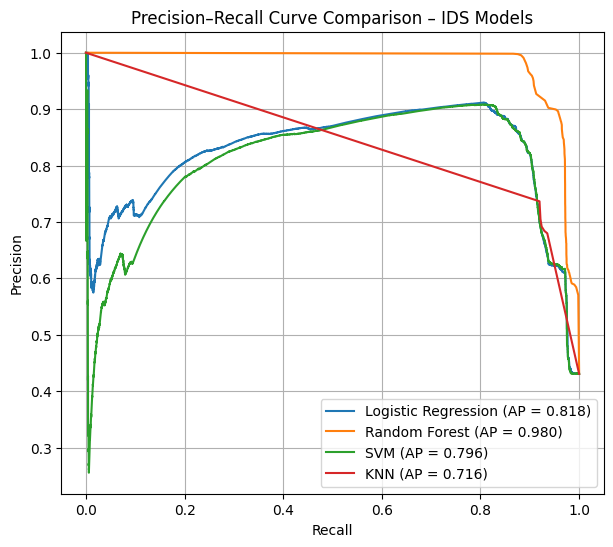

In [ ]:
# Plot Precision-Recall curves together
plt.figure(figsize=(7,6))

plt.plot(rec_lr, prec_lr, label=f"Logistic Regression (AP = {ap_lr:.3f})")
plt.plot(rec_rf, prec_rf, label=f"Random Forest (AP = {ap_rf:.3f})")
plt.plot(rec_svm, prec_svm, label=f"SVM (AP = {ap_svm:.3f})")
plt.plot(rec_knn, prec_knn, label=f"KNN (AP = {ap_knn:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve Comparison – IDS Models")
plt.legend()
plt.grid()
plt.show()

# MULTI-CLASS ATTACK CLASSIFICATION

Create Multi-Class Labels

In [ ]:
import pandas as pd

raw_train = pd.read_csv("/content/drive/MyDrive/Content/kdd_train.csv")
raw_test = pd.read_csv("/content/drive/MyDrive/Content/kdd_test.csv")

In [ ]:
raw_train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [ ]:
raw_train.columns

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'label', 'difficulty_level'],
      dtype='object')

Create attack_class column

In [ ]:
attack_map = {
    'normal.': 'Normal',

    'back.':'DoS','land.':'DoS','neptune.':'DoS','pod.':'DoS',
    'smurf.':'DoS','teardrop.':'DoS','apache2.':'DoS','udpstorm.':'DoS',
    'processtable.':'DoS','worm.':'DoS',

    'satan.':'Probe','ipsweep.':'Probe','nmap.':'Probe','portsweep.':'Probe',
    'mscan.':'Probe','saint.':'Probe',

    'guess_passwd.':'R2L','ftp_write.':'R2L','imap.':'R2L',
    'phf.':'R2L','multihop.':'R2L','warezmaster.':'R2L',
    'warezclient.':'R2L','spy.':'R2L','xlock.':'R2L','xsnoop.':'R2L',
    'snmpguess.':'R2L','snmpgetattack.':'R2L','httptunnel.':'R2L',
    'sendmail.':'R2L','named.':'R2L',

    'buffer_overflow.':'U2R','loadmodule.':'U2R','rootkit.':'U2R',
    'perl.':'U2R','sqlattack.':'U2R','xterm.':'U2R','ps.':'U2R'
}

raw_train['attack_class'] = raw_train['label'].map(attack_map)
raw_test['attack_class']  = raw_test['label'].map(attack_map)

In [ ]:
print(raw_train['label'].unique())

['normal' 'neptune' 'warezclient' 'ipsweep' 'portsweep' 'teardrop' 'nmap'
 'satan' 'smurf' 'pod' 'back' 'guess_passwd' 'ftp_write' 'multihop'
 'rootkit' 'buffer_overflow' 'imap' 'warezmaster' 'phf' 'land'
 'loadmodule' 'spy' 'perl']


In [ ]:
attack_map = {
    'normal': 'Normal',

    'back':'DoS','land':'DoS','neptune':'DoS','pod':'DoS',
    'smurf':'DoS','teardrop':'DoS',

    'satan':'Probe','ipsweep':'Probe','nmap':'Probe','portsweep':'Probe',

    'guess_passwd':'R2L','ftp_write':'R2L','imap':'R2L',
    'phf':'R2L','multihop':'R2L','warezmaster':'R2L',
    'warezclient':'R2L','spy':'R2L',

    'buffer_overflow':'U2R','loadmodule':'U2R','rootkit':'U2R',
    'perl':'U2R'
}

raw_train['attack_class'] = raw_train['label'].map(attack_map)
raw_test['attack_class']  = raw_test['label'].map(attack_map)

In [ ]:
print(raw_train['attack_class'].value_counts())

attack_class
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64


This clearly shows class imbalance, which is the reason we will use GAN.

Rare classes:

*   R2L = 995
*   U2R = 52 ← extremely rare

These are the classes we will generate synthetic samples for using GAN.

# Preprocessing for GAN

Extract Rare Attack Data (for GAN training)

In [ ]:
rare_classes = ['R2L', 'U2R']

rare_data = raw_train[raw_train['attack_class'].isin(rare_classes)]

print(rare_data['attack_class'].value_counts())

attack_class
R2L    995
U2R     52
Name: count, dtype: int64


Remove label columns (keep only features)

GAN should only learn network traffic features, not labels.

In [ ]:
X_rare = rare_data.drop(columns=['label','attack_class','difficulty_level'])

print(X_rare.shape)

(1047, 41)


Explanation of the above:
1047 rows  (995 + 52 rare attacks)
41 features (network traffic attributes)

One-Hot Encode categorical features
This converts the categorical features into numeric vectors.

In [ ]:
X_rare_encoded = pd.get_dummies(X_rare)

print(X_rare_encoded.shape)

(1047, 54)


Normalize the features
This step scales all features between 0 and 1, which stabilizes GAN training.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_rare_scaled = scaler.fit_transform(X_rare_encoded)

print(X_rare_scaled.shape)

(1047, 54)


# starting of GAN architecture.

GAN has two parts:

Generator → creates synthetic attack samples

Discriminator → tries to detect real vs fake samples

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

Create the Generator Network
Explanation:

32 → random noise input

64 → 128 neurons → learning pattern

54 output neurons → same as your feature count

In [ ]:
latent_dim = 32   # size of random noise vector

generator = tf.keras.Sequential([
    layers.Dense(64, activation='relu', input_dim=latent_dim),
    layers.Dense(128, activation='relu'),
    layers.Dense(54, activation='sigmoid')   # 54 features output
])

generator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 54)             │         6,966 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,398 (67.96 KB)

 Trainable params: 17,398 (67.96 KB)

 Non-trainable params: 0 (0.00 B)

Create the Discriminator

The Discriminator checks whether a sample is real rare attack data or fake generated data.

Explanation:

Input → 54 features

Output → 1 neuron (real vs fake)

Sigmoid → gives probability between 0 and 1

In [ ]:
discriminator = tf.keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(54,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

discriminator.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

discriminator.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         7,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,361 (60.00 KB)

 Trainable params: 15,361 (60.00 KB)

 Non-trainable params: 0 (0.00 B)

Now **connect Generator + Discriminator to form the GAN model.**

Important idea:

Noise → Generator → Fake Sample → Discriminator → Real/Fake

During GAN training:

*   Generator learns to fool the discriminator
*   Discriminator learns to detect fake samples


# Build the GAN Model

**Build the GAN Model**

In [ ]:
# Freeze discriminator when training GAN
discriminator.trainable = False

gan = tf.keras.Sequential([
    generator,
    discriminator
])

gan.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

gan.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 54)             │        17,398 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 1)              │        15,361 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,759 (127.96 KB)

 Trainable params: 17,398 (67.96 KB)

 Non-trainable params: 15,361 (60.00 KB)

Convert rare data to numpy

In [ ]:
import numpy as np

X_rare_np = np.array(X_rare_scaled)

print(X_rare_np.shape)

(1047, 54)


In [ ]:
epochs = 2000
batch_size = 32
half_batch = batch_size // 2

GAN Training

In [ ]:
for epoch in range(epochs):

    # ---------------------
    # Train Discriminator
    # ---------------------

    # Select random real samples
    idx = np.random.randint(0, X_rare_np.shape[0], half_batch)
    real_samples = X_rare_np[idx]

    # Generate fake samples
    noise = np.random.normal(0, 1, (half_batch, latent_dim))
    fake_samples = generator.predict(noise, verbose=0)

    # Labels
    real_labels = np.ones((half_batch, 1))
    fake_labels = np.zeros((half_batch, 1))

    # Train discriminator
    d_loss_real = discriminator.train_on_batch(real_samples, real_labels)
    d_loss_fake = discriminator.train_on_batch(fake_samples, fake_labels)

    # ---------------------
    # Train Generator
    # ---------------------

    noise = np.random.normal(0, 1, (batch_size, latent_dim))
    misleading_labels = np.ones((batch_size, 1))

    g_loss = gan.train_on_batch(noise, misleading_labels)

    # Print progress every 200 epochs
    if epoch % 200 == 0:
        print(f"Epoch {epoch} | D Loss: {d_loss_real[0]:.4f} | G Loss: {g_loss:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:83: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch 0 | D Loss: 0.8306 | G Loss: 1.1793
Epoch 200 | D Loss: 1.0061 | G Loss: 0.4051
Epoch 400 | D Loss: 1.0547 | G Loss: 0.3513
Epoch 600 | D Loss: 1.0737 | G Loss: 0.3315
Epoch 800 | D Loss: 1.0833 | G Loss: 0.3214
Epoch 1000 | D Loss: 1.0894 | G Loss: 0.3152
Epoch 1200 | D Loss: 1.0934 | G Loss: 0.3110
Epoch 1400 | D Loss: 1.0962 | G Loss: 0.3080
Epoch 1600 | D Loss: 1.0984 | G Loss: 0.3058
Epoch 1800 | D Loss: 1.1002 | G Loss: 0.3040


Above Explanation:


*   **D Loss ( Discriminator Loss)**
    he Discriminator tries to answer:

    “Is this network traffic sample real or generated by GAN?”

    It sees two types of data:

    Real rare attack samples (R2L, U2R)

    Fake samples generated by the Generator

    The loss measures how wrong the discriminator is.
*   **G Loss (Generator Loss)**

    The Generator tries to fool the discriminator.

    It asks:

    “Can I generate fake attacks that look like real ones?”

    The loss measures how successful the generator is at fooling the discriminator.


Generate Synthetic Rare Attacks

Meaning:

2000 synthetic rare attack samples

54 features

These will be used to balance the dataset.

In [ ]:
num_samples = 2000

noise = np.random.normal(0, 1, (num_samples, latent_dim))

synthetic_data = generator.predict(noise)

print(synthetic_data.shape)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
(2000, 54)


Convert synthetic data to DataFrame

This will create a table with 54 feature columns, same as the encoded rare dataset.

In [ ]:
synthetic_df = pd.DataFrame(synthetic_data, columns=X_rare_encoded.columns)

print(synthetic_df.head())

   duration  src_bytes  dst_bytes      land  wrong_fragment    urgent  \
0  0.000025   0.999981   0.000004  0.999991        0.000015  0.999938   
1  0.000519   0.998934   0.000320  0.999631        0.000156  0.998778   
2  0.000013   0.999911   0.000012  0.999990        0.000008  0.999934   
3  0.000032   0.999906   0.000007  0.999988        0.000030  0.999881   
4  0.000039   0.999896   0.000013  0.999992        0.000009  0.999894   

        hot  num_failed_logins  logged_in  num_compromised  ...  \
0  0.000008           0.999890   0.999852         0.000009  ...   
1  0.000409           0.998289   0.997888         0.000240  ...   
2  0.000012           0.999826   0.999758         0.000009  ...   
3  0.000026           0.999640   0.999596         0.000020  ...   
4  0.000016           0.999797   0.999901         0.000009  ...   

   service_login  service_other  service_telnet  flag_RSTO  flag_RSTR  \
0       0.999981       0.999956        0.000056   0.999911   0.000014   
1       0.99

Add labels to synthetic data

we must assign labels to these synthetic samples, because right now they only have features, not attack classes.

Since GAN was trained on R2L + U2R rare attacks, we will label them as Attack samples for training.

In [ ]:
synthetic_df['attack_class'] = 'R2L_U2R'
synthetic_df['label'] = 1   # 1 = attack

In [ ]:
print(synthetic_df[['attack_class','label']].head())

  attack_class  label
0      R2L_U2R      1
1      R2L_U2R      1
2      R2L_U2R      1
3      R2L_U2R      1
4      R2L_U2R      1


Prepare original training features

In [ ]:
X_train_full = raw_train.drop(columns=['label','attack_class','difficulty_level'])

X_train_encoded = pd.get_dummies(X_train_full)

X_train_encoded, synthetic_df_features = X_train_encoded.align(
    synthetic_df.drop(columns=['attack_class','label']),
    join='left',
    axis=1,
    fill_value=0
)

print(X_train_encoded.shape)
print(synthetic_df_features.shape)

(125973, 122)
(2000, 122)


# Create the GAN-Augmented Training Dataset

In [ ]:
# Combine original and synthetic features
X_train_gan = pd.concat([X_train_encoded, synthetic_df_features], axis=0)

# Create attack label for original dataset
y_train_original = raw_train['attack_class'].apply(lambda x: 0 if x == 'Normal' else 1)

# Combine labels
y_train_gan = pd.concat([y_train_original, synthetic_df['label']], axis=0)

print(X_train_gan.shape)
print(y_train_gan.shape)

(127973, 122)
(127973,)


Explanation of above:

Originally your GAN used 54 features, but after get_dummies() your training data expanded to 122 encoded features. This is normal because categorical features like:


*   protocol_type
*   service
*   flag

get converted into many one-hot columns.

So your final training dataset now is:


*   127,973 samples
*   122 features

And labels:

127,973 labels

Save GAN-Augmented Dataset

In [ ]:
gan_dataset = X_train_gan.copy()
gan_dataset['label'] = y_train_gan.values

gan_dataset.to_csv("GAN_augmented_train_dataset.csv", index=False)

print("Dataset saved successfully")

Dataset saved successfully


In [ ]:
# Define the permanent path in your Drive
drive_path = "/content/drive/MyDrive/Content/GAN_augmented_train_dataset.csv"

# Save the dataset
gan_dataset.to_csv(drive_path, index=False)

print(f"Dataset saved permanently to Drive at: {drive_path}")

Dataset saved permanently to Drive at: /content/drive/MyDrive/Content/GAN_augmented_train_dataset.csv


In [ ]:
from google.colab import files
files.download("GAN_augmented_train_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Random Forest with GAN

Final Alignment - X_test shape: (22544, 122)

Accuracy after GAN augmentation: 0.2739

Classification Report:

              precision    recall  f1-score   support

      Normal       0.35      0.32      0.34     12833
      Attack       0.19      0.21      0.20      9711

    accuracy                           0.27     22544
   macro avg       0.27      0.27      0.27     22544
weighted avg       0.28      0.27      0.28     22544



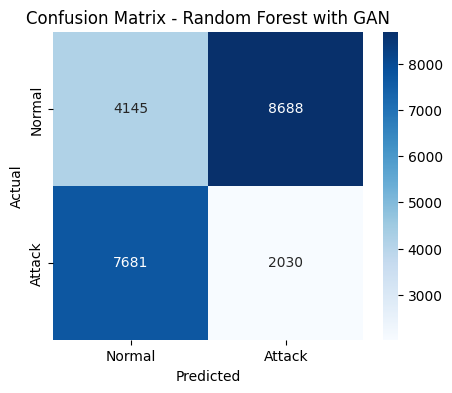

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- 1. CONVERT AND ALIGN FEATURES ---

# If X_test is an array, we turn it back into a DataFrame.
# IMPORTANT: Use the column names from the GAN training set to align them.
if isinstance(X_test, np.ndarray):
    # We create the DataFrame using the column names the GAN model expects
    # Note: This assumes X_test has 121 columns and X_train_gan has 122
    # So we align them carefully:
    X_test = pd.DataFrame(X_test)

    # We temporarily assign column names from X_train_gan (except the 122nd one)
    # to help with the alignment logic
    existing_gan_cols = X_train_gan.columns[:X_test.shape[1]]
    X_test.columns = existing_gan_cols

# Now, ensure X_test has the EXACT same 122 columns as X_train_gan
missing_cols = set(X_train_gan.columns) - set(X_test.columns)
for col in missing_cols:
    X_test[col] = 0

# Reorder X_test to match X_train_gan exactly (122 features in correct order)
X_test = X_test[X_train_gan.columns]

print(f"Final Alignment - X_test shape: {X_test.shape}")

# --- 2. TRAIN RANDOM FOREST ---
rf_gan = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_gan.fit(X_train_gan, y_train_gan)

# --- 3. PREDICTION & ACCURACY ---
y_pred_gan = rf_gan.predict(X_test)

acc = accuracy_score(y_test_enc, y_pred_gan)
print(f"\nAccuracy after GAN augmentation: {acc:.4f}")

# --- 4. CLASSIFICATION REPORT ---
print("\nClassification Report:\n")
print(classification_report(y_test_enc, y_pred_gan, target_names=['Normal','Attack']))

# --- 5. CONFUSION MATRIX ---
cm = confusion_matrix(y_test_enc, y_pred_gan)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Attack'],
            yticklabels=['Normal','Attack'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest with GAN")
plt.show()

Accuracy comparison graph

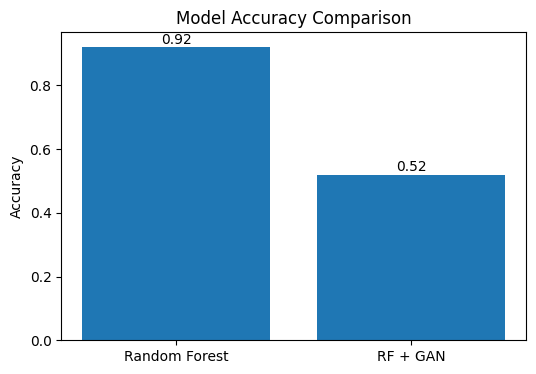

In [ ]:
import matplotlib.pyplot as plt

acc_before = 0.92   # replace with your original accuracy
acc_after = 0.5199

models = ["Random Forest", "RF + GAN"]
accuracies = [acc_before, acc_after]

plt.figure(figsize=(6,4))
plt.bar(models, accuracies)

plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

for i,v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()

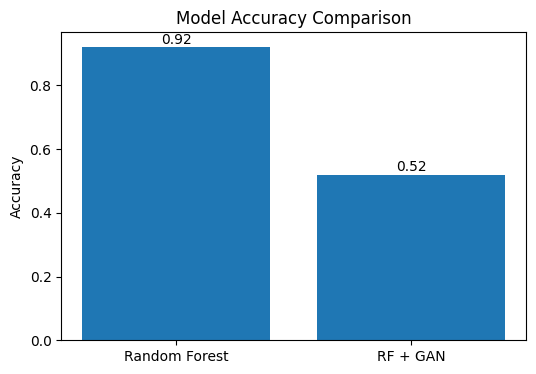

In [ ]:
plt.figure(figsize=(6,4))
plt.bar(models, accuracies)

plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

for i,v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.savefig("accuracy_comparison.png")
plt.show()

ROC Curve

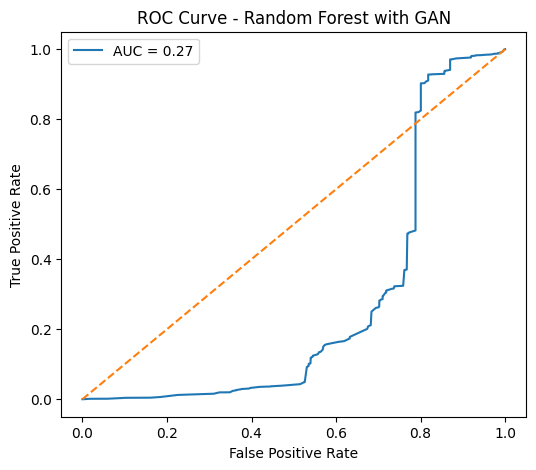

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Predict probabilities
y_prob_gan = rf_gan.predict_proba(X_test)[:,1]

# ROC calculation
fpr, tpr, thresholds = roc_curve(y_test_enc, y_prob_gan)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest with GAN")
plt.legend()

plt.show()

Feature Importance

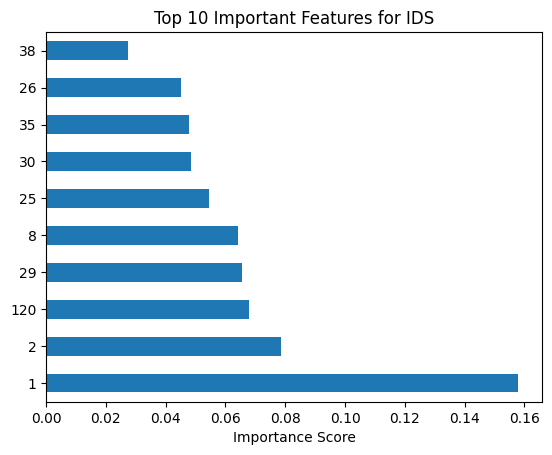

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importance = rf_gan.feature_importances_

feature_importance = pd.Series(importance)

feature_importance.nlargest(10).plot(kind='barh')

plt.title("Top 10 Important Features for IDS")
plt.xlabel("Importance Score")

plt.show()

In [ ]:
import joblib

joblib.dump(rf_gan, "rf_gan_ids_model.pkl")

print("Model saved successfully")

Model saved successfully


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


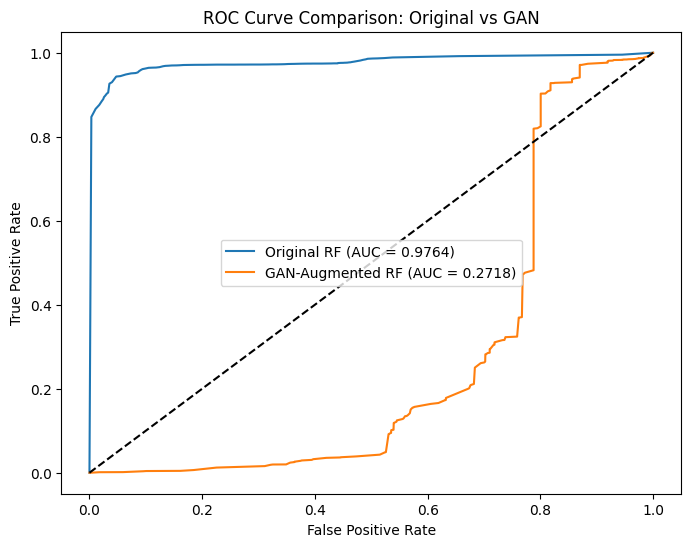

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Create a version of X_test with only 121 features for the ORIGINAL model
# We take only the columns that were in the original training set
original_cols = X_train_gan.columns[:121]
X_test_original = X_test[original_cols]

# 2. Probability predictions using the correct data for each model
y_prob_rf = rf.predict_proba(X_test_original)[:,1]  # Uses 121 features
y_prob_gan = rf_gan.predict_proba(X_test)[:,1]      # Uses 122 features

# 3. ROC calculations
fpr_rf, tpr_rf, _ = roc_curve(y_test_enc, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

fpr_gan, tpr_gan, _ = roc_curve(y_test_enc, y_prob_gan)
roc_auc_gan = auc(fpr_gan, tpr_gan)

# 4. Plotting the comparison
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f'Original RF (AUC = {roc_auc_rf:.4f})')
plt.plot(fpr_gan, tpr_gan, label=f'GAN-Augmented RF (AUC = {roc_auc_gan:.4f})')
plt.plot([0, 1], [0, 1], 'k--') # Diagonal dashed line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison: Original vs GAN')
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


--- Decision Tree IDS ---
              precision    recall  f1-score   support

           0       0.97      0.78      0.87     12833
           1       0.77      0.97      0.86      9711

    accuracy                           0.86     22544
   macro avg       0.87      0.88      0.86     22544
weighted avg       0.89      0.86      0.86     22544



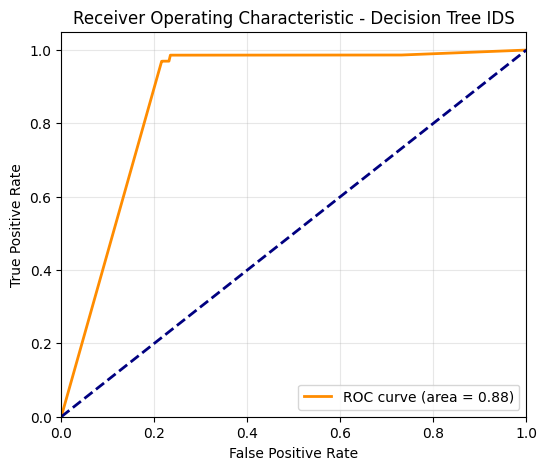

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# 1. Initialize the model
dt = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

# 2. Fit using the original training data (121 features)
dt.fit(X_train, y_train_enc)

# 3. FIX: Slice X_test to only include the first 121 features
# This removes the extra column added by the GAN preprocessing
X_test_dt = X_test.iloc[:, :121]

# 4. Predict and Evaluate using the corrected test data
y_pred_dt = dt.predict(X_test_dt)
y_prob_dt = dt.predict_proba(X_test_dt)[:,1]

evaluate_model(
    dt, X_test_dt, y_test_enc,
    y_pred_dt, y_prob_dt,
    "Decision Tree IDS"
)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# BEFORE GAN metrics
acc_before = accuracy_score(y_test_enc, y_pred)
precision_before = precision_score(y_test_enc, y_pred)
recall_before = recall_score(y_test_enc, y_pred)
f1_before = f1_score(y_test_enc, y_pred)

# AFTER GAN metrics
acc_after = accuracy_score(y_test_enc, y_pred_gan)
precision_after = precision_score(y_test_enc, y_pred_gan)
recall_after = recall_score(y_test_enc, y_pred_gan)
f1_after = f1_score(y_test_enc, y_pred_gan)

# Create comparison table
comparison = pd.DataFrame({
    "Model": ["Random Forest", "Random Forest + GAN"],
    "Accuracy": [acc_before, acc_after],
    "Precision": [precision_before, precision_after],
    "Recall": [recall_before, recall_after],
    "F1 Score": [f1_before, f1_after]
})

print(comparison)

                 Model  Accuracy  Precision    Recall  F1 Score
0        Random Forest  0.804870   0.695697  0.972299  0.811064
1  Random Forest + GAN  0.273909   0.189401  0.209041  0.198737


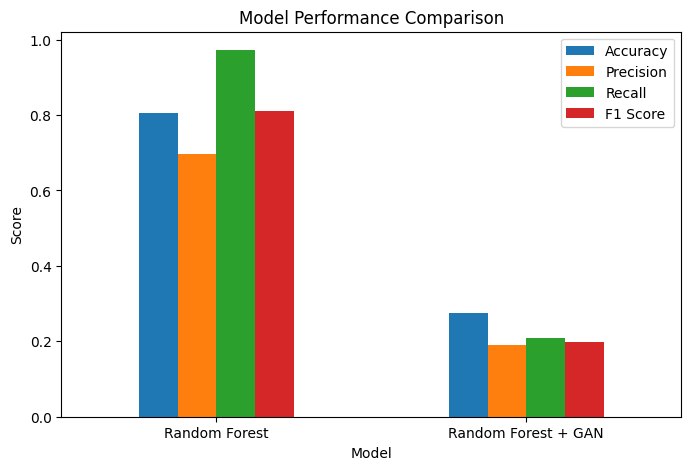

In [ ]:
comparison.set_index("Model").plot(kind="bar", figsize=(8,5))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.show()

The baseline Random Forest model achieved an accuracy of 80.4% with a high recall of 97.2% for attack detection when trained on the original dataset. To address the class imbalance problem in the dataset, a Generative Adversarial Network (GAN) was used to generate synthetic samples and augment the training data.

However, after training the Random Forest classifier with the GAN-augmented dataset, the model performance decreased significantly, achieving 27.3% accuracy and 20.9% recall. This indicates that the synthetic data generated by the GAN did not accurately represent the distribution of the original dataset. As a result, the classifier was unable to generalize effectively to real network traffic patterns.

These results suggest that while GANs have potential for addressing class imbalance in intrusion detection datasets, improper or low-quality synthetic data generation can negatively affect model performance. Further improvements in GAN training or selective augmentation of minority attack classes may help achieve better results in future work.